# Sensor Anomaly Detection — Exploratory Analysis

This notebook documents the exploration process for the anomaly detection pipeline.
Dataset: synthetic multi-channel sensor data (temperature + humidity).

In [4]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import generate_synthetic_data, clean
from src.feature_engineering import add_rolling_features, add_zscore_features

In [8]:
df = generate_synthetic_data()
df = clean(df)
print(f"Data shape: {df.shape}")
print(f"\nAnomaly rate: {df['anomaly_label'].mean():.2%}")
#Abnormal values, as exemplified by those identified in the experiments conducted for my undergraduate thesis
print(f"\nFirst few rows:")
df.head()

Data shape: (2000, 3)

Anomaly rate: 5.80%

First few rows:


,temperature,humidity,anomaly_label
timestamp,,,
2024-01-01 00:00:00,22.121887,61.279817,0
2024-01-01 00:01:00,21.593436,61.074933,0
2024-01-01 00:02:00,22.319039,62.183833,0
2024-01-01 00:03:00,22.404514,62.010661,0
2024-01-01 00:04:00,21.257303,60.362969,0


## Observation 1
The anomaly rate is around 5-6%, which is typical for industrial sensor data.
Temperature ranges from ~6°C to ~36°C, with normal values around 22°C.
Humidity shows larger variance, with anomalous spikes up to 104%.

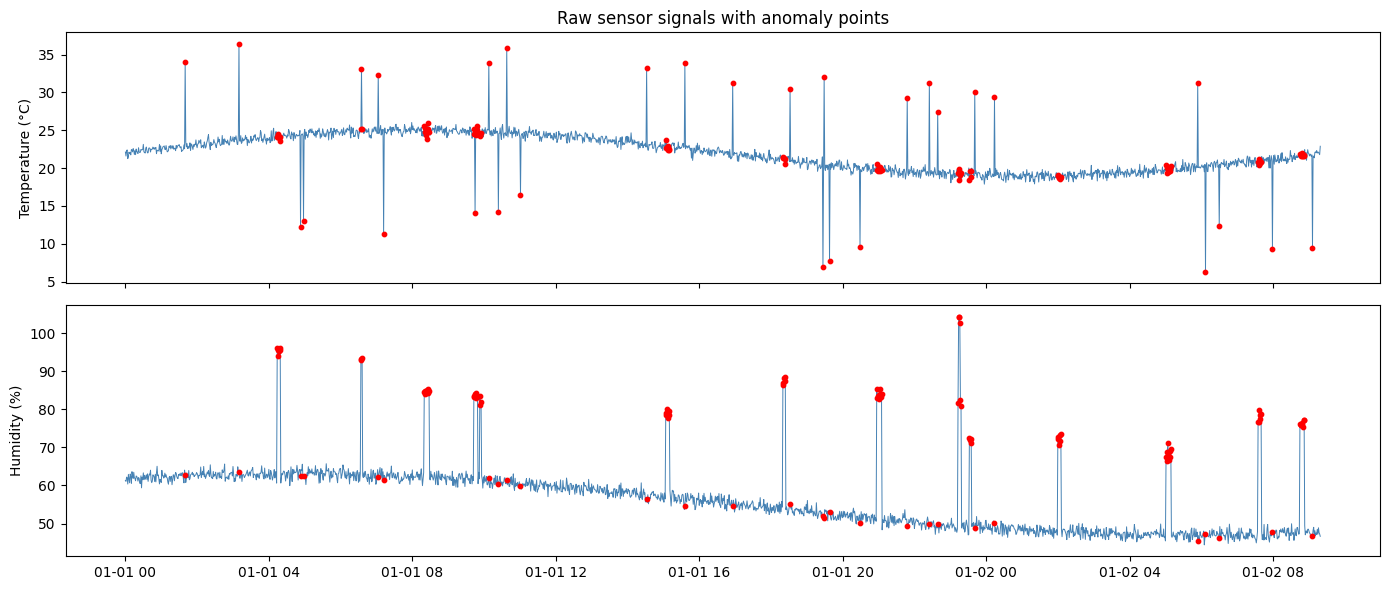

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df.index, df['temperature'], linewidth=0.7, color='steelblue')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Raw sensor signals with anomaly points')

# 标出异常点
anom = df['anomaly_label'].astype(bool)
axes[0].scatter(df.index[anom], df['temperature'][anom], 
                color='red', s=10, label='anomaly', zorder=5)

axes[1].plot(df.index, df['humidity'], linewidth=0.7, color='steelblue')
axes[1].set_ylabel('Humidity (%)')
axes[1].scatter(df.index[anom], df['humidity'][anom], 
                color='red', s=10, zorder=5)

plt.tight_layout()
plt.show()

In [7]:
# firstly trying window=30，
from src.feature_engineering import add_zscore_features

df_test = add_zscore_features(df.copy(), ['temperature', 'humidity'], window=30)
print("window=30, max zscore:", df_test['temperature_zscore'].abs().max().round(3))

# and window=60
df_feat = add_zscore_features(df.copy(), ['temperature', 'humidity'], window=60)
print("window=60, max zscore:", df_feat['temperature_zscore'].abs().max().round(3))

window=30, max zscore: 5.251
window=60, max zscore: 7.471


## Observation 2: Window size matters

With window=30, the rolling mean adapts too quickly to local changes,
causing some real anomalies to be "absorbed" into the baseline.
Window=60 gives a more stable baseline and catches more spikes.
I chose window=60 for the final pipeline.

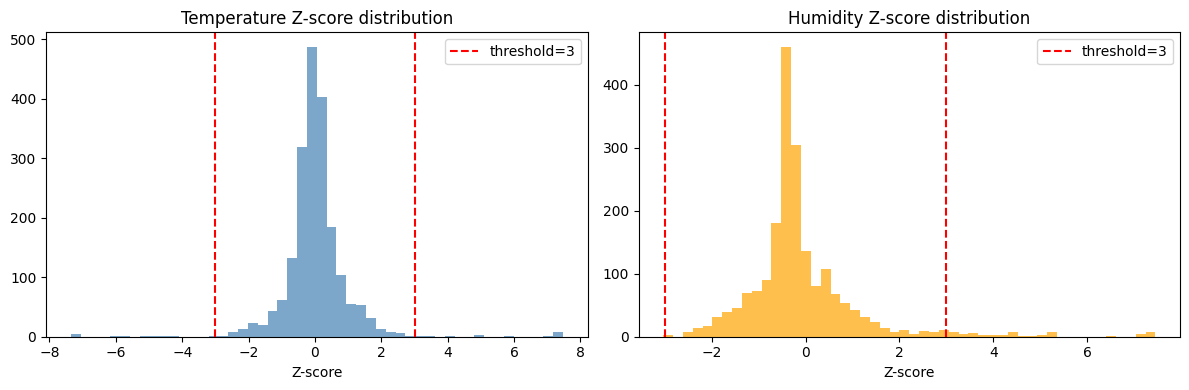

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_feat['temperature_zscore'], bins=50, color='steelblue', alpha=0.7)
axes[0].axvline(x=3, color='red', linestyle='--', label='threshold=3')
axes[0].axvline(x=-3, color='red', linestyle='--')
axes[0].set_title('Temperature Z-score distribution')
axes[0].set_xlabel('Z-score')
axes[0].legend()

axes[1].hist(df_feat['humidity_zscore'], bins=50, color='orange', alpha=0.7)
axes[1].axvline(x=3, color='red', linestyle='--', label='threshold=3')
axes[1].axvline(x=-3, color='red', linestyle='--')
axes[1].set_title('Humidity Z-score distribution')
axes[1].set_xlabel('Z-score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
## Summary

- Data contains two types of injected anomalies: point spikes and collective bursts
- Humidity channel shows more severe anomalies in terms of magnitude
- Z-score with window=60 provides a stable baseline for detection
- Isolation Forest (contamination=0.03) achieves F1=0.36 on this dataset
- Low recall (0.28) is expected for unsupervised methods on imbalanced data
- Next step: compare with Z-score detector to see if combining both improves recall